# 🔐 Distorted Visual Sequence Pattern Recognition
## 6-Head EfficientNet-B0 CAPTCHA Classifier
**Architecture:** EfficientNet-B0 → GlobalAvgPool → 6 × Linear(31 classes)  
**Loss:** Sum of 6 CrossEntropy losses with label smoothing  
**Metric:** Character Error Rate (CER) via Levenshtein Distance  

> Upload `cig_ps.zip` to your Google Drive and update `ZIP_PATH` below.


In [1]:
import zipfile

with zipfile.ZipFile('/content/cig_ps.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/cig_ps')

print("Done")

Done


## 1 · Install Dependencies & Imports

In [2]:
# Install required packages (only what's not in Colab by default)
!pip install timm torchmetrics albumentations python-Levenshtein -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.7 MB/s eta 0:00:00


In [3]:
import os, sys, zipfile, random, time, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from Levenshtein import distance as levenshtein_distance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2 · Configuration

In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                     EDIT THESE PATHS                                ║
# ╚══════════════════════════════════════════════════════════════════════╝
ZIP_PATH       = "/content/cig_ps.zip"   # path to uploaded zip
WORK_DIR       = "/content/cig_ps"                   # extraction target
CHECKPOINT_DIR = "/content/checkpoints" # where to save models

# ── Dataset ──────────────────────────────────────────────────────────────────
IMG_H          = 100
IMG_W          = 200
SEQ_LEN        = 6          # fixed sequence length

# Vocabulary: uppercase + digits, excluding I L O 0 1 (classic CAPTCHA)
VOCAB          = sorted("23456789ABCDEFGHJKMNPQRSTUVWXYZ")
VOCAB_SIZE     = len(VOCAB)                          # 31
CHAR2IDX       = {c: i for i, c in enumerate(VOCAB)}
IDX2CHAR       = {i: c for c, i in CHAR2IDX.items()}
print(f"Vocabulary ({VOCAB_SIZE} chars): {''.join(VOCAB)}")

# ── Training ─────────────────────────────────────────────────────────────────
VAL_FRACTION   = 0.10        # 10% of train → validation
BATCH_SIZE     = 128
NUM_WORKERS    = 2
NUM_EPOCHS     = 80
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 1e-4
LABEL_SMOOTHING= 0.1
PATIENCE       = 12          # early stopping patience
MIN_DELTA      = 1e-4        # minimum CER improvement to reset patience

# ── Model ─────────────────────────────────────────────────────────────────────
BACKBONE       = "efficientnet_b0"
DROPOUT        = 0.40
HIDDEN_DIM     = 256

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Config loaded ✓")


Vocabulary (31 chars): 23456789ABCDEFGHJKMNPQRSTUVWXYZ
Config loaded ✓


## 3 · Mount Drive & Extract Dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


In [5]:
# Extract dataset (skip if already extracted)
TRAIN_DIR = Path("/content/cig_ps/cig_ps/train_images")
TEST_DIR  = Path("/content/cig_ps/cig_ps/test_images")
CSV_PATH  = Path("/content/cig_ps/cig_ps/train-labels.csv")

if not TRAIN_DIR.exists():
    print("Extracting zip …")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(WORK_DIR)
    # Zip may contain a nested folder — move files up if needed
    nested = list(Path(WORK_DIR).glob("*/train_images"))
    if nested:
        import shutil
        base = nested[0].parent
        for item in base.iterdir():
            shutil.move(str(item), WORK_DIR)
        base.rmdir()
    print("Extraction complete ✓")
else:
    print("Already extracted ✓")

n_train = len(list(TRAIN_DIR.glob("*.png")))
n_test  = len(list(TEST_DIR.glob("*.png")))
print(f"Train images : {n_train:,}")
print(f"Test  images : {n_test:,}")


Already extracted ✓
Train images : 20,000
Test  images : 5,000


## 4 · Exploratory Data Analysis

In [6]:
# Load labels
df = pd.read_csv(CSV_PATH)
df.columns = ["idx", "image", "text"] if len(df.columns) == 3 else ["image", "text"]
df = df[["image", "text"]].copy()

# ── Clean anomalies ───────────────────────────────────────────────────────────
original_len = len(df)
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() == SEQ_LEN].reset_index(drop=True)
df = df[df["text"].str.fullmatch(f"[{''.join(VOCAB)}]{{{SEQ_LEN}}}")].reset_index(drop=True)
print(f"Rows before cleaning : {original_len:,}")
print(f"Rows after  cleaning : {len(df):,}  (dropped {original_len - len(df)} anomalous labels)")
df.head(10)


Rows before cleaning : 20,000
Rows after  cleaning : 19,998  (dropped 2 anomalous labels)


,image,text
0,train-0.png,BU522X
1,train-1.png,XQ8NE2
2,train-2.png,DTZD3E
3,train-3.png,SM424H
4,train-4.png,6YVTQR
5,train-5.png,YV2C3D
6,train-6.png,XNBP7G
7,train-7.png,TGQXFU
8,train-8.png,36B667
9,train-9.png,QJ6HDR


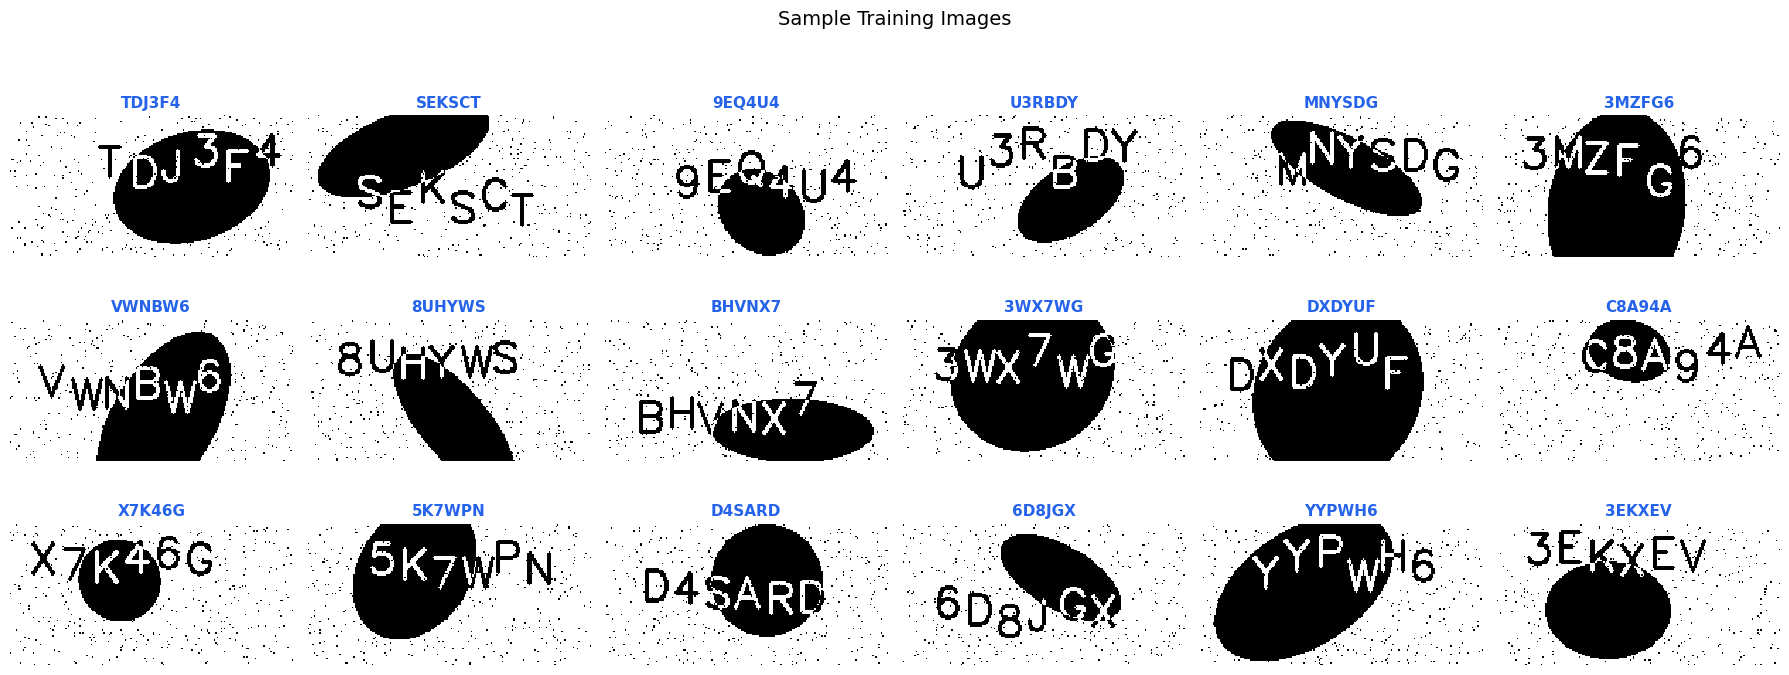

In [7]:
# ── Visualise sample images ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(18, 7))
sample = df.sample(18, random_state=SEED).reset_index(drop=True)
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(TRAIN_DIR / row["image"]).convert("L")
    ax.imshow(img, cmap="gray", interpolation="nearest")
    ax.set_title(row["text"], fontsize=11, fontweight="bold", color="#2563eb")
    ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


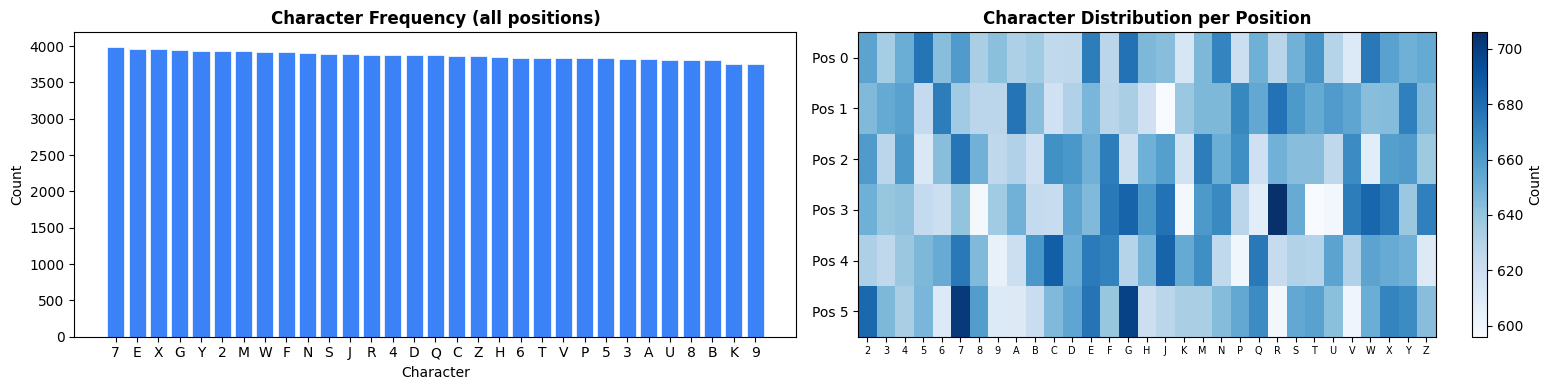

Chars are uniformly distributed across positions: ✓


In [8]:
# ── Character frequency analysis ─────────────────────────────────────────────
from collections import Counter
all_chars = "".join(df["text"].tolist())
freq = Counter(all_chars)
chars_sorted = sorted(freq, key=freq.get, reverse=True)
counts = [freq[c] for c in chars_sorted]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(chars_sorted, counts, color="#3b82f6", edgecolor="white", linewidth=0.5)
axes[0].set_title("Character Frequency (all positions)", fontweight="bold")
axes[0].set_xlabel("Character"); axes[0].set_ylabel("Count")

# Per-position distribution (stacked)
pos_counts = np.zeros((SEQ_LEN, VOCAB_SIZE))
for text in df["text"]:
    for p, c in enumerate(text):
        if c in CHAR2IDX:
            pos_counts[p, CHAR2IDX[c]] += 1

im = axes[1].imshow(pos_counts, aspect="auto", cmap="Blues")
axes[1].set_xticks(range(VOCAB_SIZE)); axes[1].set_xticklabels(VOCAB, fontsize=7)
axes[1].set_yticks(range(SEQ_LEN));   axes[1].set_yticklabels([f"Pos {i}" for i in range(SEQ_LEN)])
axes[1].set_title("Character Distribution per Position", fontweight="bold")
plt.colorbar(im, ax=axes[1], label="Count")
plt.tight_layout(); plt.show()
print(f"Chars are uniformly distributed across positions: ✓")


## 5 · Dataset & Augmentation Pipeline

In [9]:
# ── Albumentations augmentation pipelines ─────────────────────────────────────
#
# Key insight: images are BINARY (0/240 pixels), so:
#   - No colour jitter needed
#   - Noise augmentation would clash with existing heavy noise
#   - Geometric distortions + mild blur + erosion/dilation are most useful

TRAIN_TRANSFORMS = A.Compose([
    # Slight geometric perturbations
    A.ShiftScaleRotate(
        shift_limit=0.04, scale_limit=0.04, rotate_limit=3,
        border_mode=0, p=0.6
    ),
    # Simulates stroke width variation (key for binary CAPTCHA)
    A.OneOf([
        A.Morphological(operation="dilation", p=1.0),
        A.Morphological(operation="erosion",  p=1.0),
    ], p=0.4),
    # Mild blur to smooth salt-and-pepper noise
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 3), p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.5),
    # Random occlusion patches
    A.CoarseDropout(
        num_holes_range=(1, 3),
        hole_height_range=(5, 15),
        hole_width_range=(5, 20),
        fill=240,   # fill with background colour
        p=0.3
    ),
    # Elastic distortion (subtle character warping)
    A.ElasticTransform(alpha=10, sigma=3, p=0.2),
    # Normalise to [0,1] and convert to tensor
    A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),
    ToTensorV2(),   # → C×H×W float32
])

VAL_TRANSFORMS = A.Compose([
    A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),
    ToTensorV2(),
])

TEST_TRANSFORMS = VAL_TRANSFORMS  # identical to val


In [10]:
class CAPTCHADataset(Dataset):
    """
    Loads CAPTCHA images and encodes labels as 6 integer class indices.
    Returns (image_tensor [1,H,W], targets [6]) for training,
            (image_tensor, filename) for test mode.
    """

    def __init__(self, df=None, img_dir=None, transforms=None, test_mode=False):
        self.test_mode  = test_mode
        self.transforms = transforms

        if test_mode:
            self.img_dir = Path(img_dir)
            self.files   = sorted(self.img_dir.glob("*.png"),
                                  key=lambda p: int(p.stem.split("-")[1]))
        else:
            self.img_dir = Path(img_dir)
            self.df      = df.reset_index(drop=True)

    def __len__(self):
        return len(self.files) if self.test_mode else len(self.df)

    def _load_gray(self, path: Path) -> np.ndarray:
        """Load PNG as uint8 grayscale HxW numpy array."""
        img = Image.open(path).convert("L")
        return np.array(img, dtype=np.uint8)

    def _encode(self, text: str) -> torch.LongTensor:
        return torch.tensor([CHAR2IDX[c] for c in text], dtype=torch.long)

    def __getitem__(self, idx):
        if self.test_mode:
            path  = self.files[idx]
            arr   = self._load_gray(path)
            arr   = arr[:, :, np.newaxis]          # H×W×1 for albumentations
            if self.transforms:
                arr = self.transforms(image=arr)["image"]   # → 1×H×W
            return arr, path.name

        row  = self.df.iloc[idx]
        arr  = self._load_gray(self.img_dir / row["image"])
        arr  = arr[:, :, np.newaxis]
        if self.transforms:
            arr = self.transforms(image=arr)["image"]
        targets = self._encode(row["text"])
        return arr, targets


def build_loaders(df, train_dir, test_dir):
    """Split df into train/val, return all three DataLoaders."""
    n_val   = int(len(df) * VAL_FRACTION)
    n_train = len(df) - n_val

    # Reproducible split
    g = torch.Generator().manual_seed(SEED)
    train_df, val_df = random_split(df.index.tolist(), [n_train, n_val], generator=g)
    train_df = df.iloc[list(train_df)].reset_index(drop=True)
    val_df   = df.iloc[list(val_df)  ].reset_index(drop=True)

    train_ds = CAPTCHADataset(train_df, train_dir, TRAIN_TRANSFORMS)
    val_ds   = CAPTCHADataset(val_df,   train_dir, VAL_TRANSFORMS)
    test_ds  = CAPTCHADataset(test_mode=True, img_dir=test_dir, transforms=TEST_TRANSFORMS)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    print(f"Train : {len(train_ds):,} images  |  "
          f"Val : {len(val_ds):,} images  |  "
          f"Test : {len(test_ds):,} images")
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_loaders(df, TRAIN_DIR, TEST_DIR)

# ── Verify a batch ────────────────────────────────────────────────────────────
imgs, tgts = next(iter(train_loader))
print(f"Batch tensors : images {tuple(imgs.shape)}  targets {tuple(tgts.shape)}")
print(f"Pixel range   : [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"Sample labels : {[''.join(IDX2CHAR[i.item()] for i in t) for t in tgts[:6]]}")


Train : 17,999 images  |  Val : 1,999 images  |  Test : 5,000 images
Batch tensors : images (128, 1, 100, 200)  targets (128, 6)
Pixel range   : [-1.00, 0.88]
Sample labels : ['X329YU', '68BUFN', 'QEK9TQ', '8MMJW2', 'U47G3J', 'V5BCXS']


## 6 · Model Architecture

In [11]:
class SixHeadCAPTCHANet(nn.Module):
    """
    EfficientNet-B0 backbone with 6 independent classification heads.

    Architecture
    ────────────
    Input  : [B, 1, 100, 200]  (grayscale CAPTCHA)
    Stem   : Conv1×1 1→3 channels  (adapt grayscale → EfficientNet expected input)
    Backbone: EfficientNet-B0 (pretrained on ImageNet), features only
    Pool   : AdaptiveAvgPool2d → [B, 1280]
    Shared : Linear(1280→HIDDEN_DIM) → BN → ReLU → Dropout(p)
    Heads  : 6 × Linear(HIDDEN_DIM→VOCAB_SIZE)  — one per character position
    Output : list of 6 tensors, each [B, VOCAB_SIZE]  (raw logits)
    """

    def __init__(self, backbone_name=BACKBONE, hidden=HIDDEN_DIM,
                 vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, dropout=DROPOUT):
        super().__init__()
        self.seq_len = seq_len

        # 1-channel → 3-channel adapter (learned, lightweight)
        self.input_adapt = nn.Sequential(
            nn.Conv2d(1, 3, kernel_size=1, bias=False),
            nn.BatchNorm2d(3),
        )

        # EfficientNet-B0 — strip classifier, keep feature extractor
        base = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.backbone = base       # timm's num_classes=0 → outputs feature map then pools

        feat_dim = base.num_features   # 1280 for efficientnet_b0

        # Shared projection head
        self.shared = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
        )

        # 6 independent classification heads
        self.heads = nn.ModuleList([
            nn.Linear(hidden, vocab_size) for _ in range(seq_len)
        ])

        self._init_weights()

    def _init_weights(self):
        nn.init.kaiming_normal_(self.input_adapt[0].weight, mode="fan_out")
        for head in self.heads:
            nn.init.xavier_uniform_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, x):
        # x: [B, 1, H, W]
        x = self.input_adapt(x)          # [B, 3, H, W]
        x = self.backbone(x)             # [B, feat_dim]  (timm pools internally)
        x = self.shared(x)               # [B, hidden]
        logits = [head(x) for head in self.heads]   # 6 × [B, vocab_size]
        return logits                    # list of 6


# ── Instantiate & inspect ─────────────────────────────────────────────────────
model = SixHeadCAPTCHANet().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params/1e6:.2f}M")
print(f"Trainable params : {trainable_params/1e6:.2f}M")

# Quick forward pass sanity check
with torch.no_grad():
    dummy   = torch.randn(4, 1, IMG_H, IMG_W).to(DEVICE)
    outputs = model(dummy)
    print(f"Output shapes    : {[tuple(o.shape) for o in outputs]}")
    print(f"Expected         : 6 × (4, {VOCAB_SIZE})")
print("Model OK ✓")


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total params     : 4.38M
Trainable params : 4.38M
Output shapes    : [(4, 31), (4, 31), (4, 31), (4, 31), (4, 31), (4, 31)]
Expected         : 6 × (4, 31)
Model OK ✓


## 7 · Loss Function & Evaluation Metrics

In [12]:
class MultiHeadCrossEntropy(nn.Module):
    """
    Sum of CrossEntropy losses across all 6 character positions.
    Label smoothing improves calibration and reduces overconfidence.
    """
    def __init__(self, label_smoothing=LABEL_SMOOTHING):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    def forward(self, logits_list, targets):
        """
        logits_list : list of 6 tensors, each [B, VOCAB_SIZE]
        targets     : [B, SEQ_LEN] long tensor
        """
        loss = sum(
            self.ce(logits_list[i], targets[:, i])
            for i in range(SEQ_LEN)
        )
        return loss


def decode_predictions(logits_list):
    """
    Convert list of 6 logit tensors → list of predicted strings.
    logits_list: 6 × [B, VOCAB_SIZE]
    returns    : list of B strings
    """
    # Stack to [B, SEQ_LEN, VOCAB_SIZE], argmax over vocab dim
    stacked = torch.stack(logits_list, dim=1)     # [B, 6, V]
    indices = stacked.argmax(dim=2)               # [B, 6]
    preds   = []
    for row in indices.cpu().numpy():
        preds.append("".join(IDX2CHAR[i] for i in row))
    return preds


def compute_cer(predictions, targets):
    """
    Character Error Rate = mean Levenshtein(pred, gt) / len(gt).
    Lower is better; 0.0 = perfect.
    """
    errors = 0.0
    total  = 0
    for pred, gt in zip(predictions, targets):
        errors += levenshtein_distance(pred, gt)
        total  += len(gt)
    return errors / total if total > 0 else 0.0


def compute_word_accuracy(predictions, targets):
    """Fraction of fully-correct sequence predictions (word-level)."""
    correct = sum(p == t for p, t in zip(predictions, targets))
    return correct / len(targets) if targets else 0.0


# ── Unit tests ────────────────────────────────────────────────────────────────
assert compute_cer(["ABCDEF"], ["ABCDEF"]) == 0.0,   "CER perfect failed"
assert compute_cer(["ABCDEF"], ["ABCDEG"]) == 1/6,   "CER 1 sub failed"
assert compute_cer(["AAAAAA"], ["BBBBBB"]) == 1.0,   "CER all wrong failed"
assert compute_word_accuracy(["ABCDEF"], ["ABCDEF"]) == 1.0
assert compute_word_accuracy(["ABCDEF"], ["ABCDEG"]) == 0.0
print("Loss & metric tests passed ✓")


Loss & metric tests passed ✓


## 8 · Training Loop

In [13]:
class EarlyStopping:
    """
    Monitors validation CER; stops training when no improvement
    for `patience` consecutive epochs.
    """
    def __init__(self, patience=PATIENCE, min_delta=MIN_DELTA, mode="min"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.best       = float("inf") if mode == "min" else -float("inf")
        self.counter    = 0
        self.best_epoch = 0
        self.stop       = False

    def step(self, metric, epoch):
        improved = (self.mode == "min" and metric < self.best - self.min_delta) or \
                   (self.mode == "max" and metric > self.best + self.min_delta)
        if improved:
            self.best       = metric
            self.counter    = 0
            self.best_epoch = epoch
            return True   # signal: save checkpoint
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
            return False


In [14]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    """One full pass over the training set. Returns avg loss."""
    model.train()
    running_loss = 0.0
    n_batches    = 0

    for imgs, targets in tqdm(loader, desc="  train", leave=False):
        imgs    = imgs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)  # [B, 6]

        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        n_batches    += 1

    return running_loss / n_batches


@torch.no_grad()
def evaluate(model, loader):
    """Run validation. Returns (avg_loss, CER, word_accuracy)."""
    model.eval()
    criterion = MultiHeadCrossEntropy()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in tqdm(loader, desc="  val  ", leave=False):
        imgs    = imgs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, targets)

        running_loss += loss.item()

        preds = decode_predictions(logits)
        gt    = ["".join(IDX2CHAR[i.item()] for i in t) for t in targets.cpu()]
        all_preds.extend(preds)
        all_targets.extend(gt)

    avg_loss  = running_loss / len(loader)
    cer       = compute_cer(all_preds, all_targets)
    word_acc  = compute_word_accuracy(all_preds, all_targets)
    return avg_loss, cer, word_acc


In [15]:
def train(model, train_loader, val_loader,
          num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """
    Full training loop with:
      - Mixed precision (AMP)
      - Cosine annealing LR schedule with warm restarts
      - Early stopping on validation CER
      - Best-model checkpointing
    """
    criterion = MultiHeadCrossEntropy().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    scaler        = GradScaler()
    early_stopper = EarlyStopping()
    best_ckpt     = Path(CHECKPOINT_DIR) / "best_model.pth"

    history = {
        "train_loss": [], "val_loss": [],
        "val_cer": [],    "val_word_acc": [],
        "lr": []
    }

    print(f"{'Epoch':>5} {'LR':>9} {'Train Loss':>11} "
          f"{'Val Loss':>9} {'Val CER':>8} {'Word Acc':>9} {'':>6}")
    print("─" * 65)

    for epoch in range(1, num_epochs + 1):
        t0         = time.time()
        train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_cer, val_acc = evaluate(model, val_loader)
        lr_now     = optimizer.param_groups[0]["lr"]
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_cer"].append(val_cer)
        history["val_word_acc"].append(val_acc)
        history["lr"].append(lr_now)

        improved = early_stopper.step(val_cer, epoch)
        flag     = "★" if improved else ""

        print(f"{epoch:>5}  {lr_now:>9.2e}  {train_loss:>11.4f}  "
              f"{val_loss:>9.4f}  {val_cer:>8.4f}  {val_acc:>8.2%}  {flag}")

        if improved:
            torch.save({
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "val_cer":     val_cer,
                "val_word_acc":val_acc,
                "vocab":       VOCAB,
            }, best_ckpt)

        if early_stopper.stop:
            print(f"\nEarly stopping triggered. Best epoch: {early_stopper.best_epoch} "
                  f"| Best CER: {early_stopper.best:.4f}")
            break

    print(f"\nTraining complete. Best CER = {early_stopper.best:.4f} "
          f"at epoch {early_stopper.best_epoch}")
    print(f"Checkpoint saved to: {best_ckpt}")
    return history


# ── Run training ──────────────────────────────────────────────────────────────
history = train(model, train_loader, val_loader)


Epoch        LR  Train Loss  Val Loss  Val CER  Word Acc       
─────────────────────────────────────────────────────────────────


  train:   0%|          | 0/140 [00:00<?, ?it/s]

  val  :   0%|          | 0/16 [00:00<?, ?it/s]

    1   1.00e-03      21.3991    20.1305    0.9274     0.00%  ★


  train:   0%|          | 0/140 [00:00<?, ?it/s]

...

  val  :   0%|          | 0/16 [00:00<?, ?it/s]

   31   1.00e-03       5.1219     4.2319    0.0010    99.40%  


  train:   0%|          | 0/140 [00:00<?, ?it/s]

  val  :   0%|          | 0/16 [00:00<?, ?it/s]

   32   9.98e-04       5.1543     4.2053    0.0008    99.50%  

Early stopping triggered. Best epoch: 20 | Best CER: 0.0002

Training complete. Best CER = 0.0002 at epoch 20
Checkpoint saved to: /content/checkpoints/best_model.pth


## 9 · Training Curves

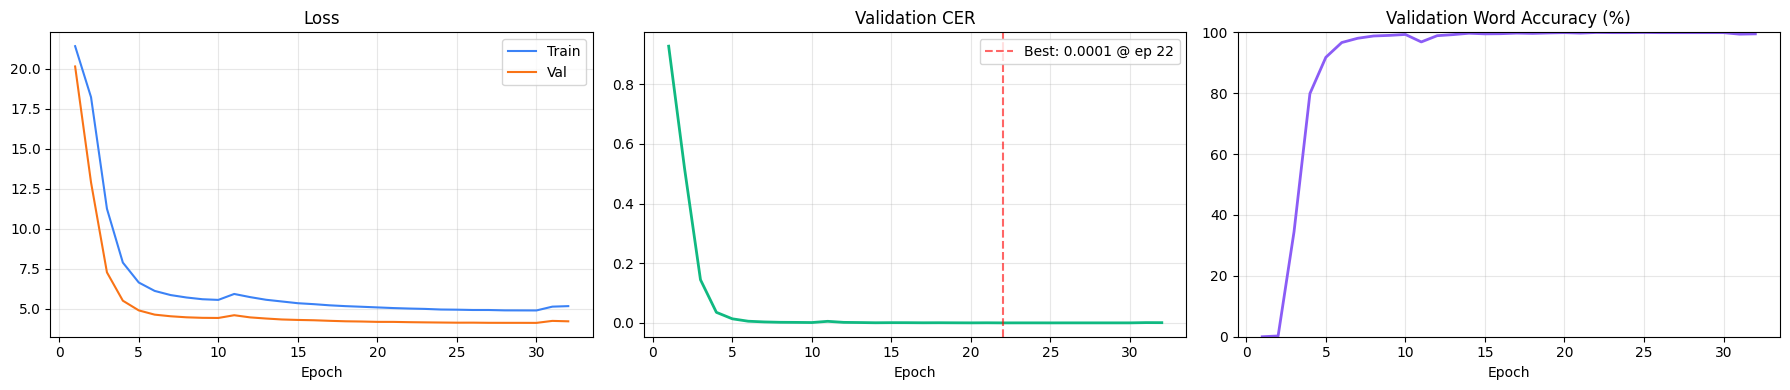

In [16]:
def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train", color="#3b82f6")
    axes[0].plot(epochs, history["val_loss"],   label="Val",   color="#f97316")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[0].grid(alpha=0.3)

    # CER
    axes[1].plot(epochs, history["val_cer"], color="#10b981", linewidth=2)
    best_epoch = history["val_cer"].index(min(history["val_cer"])) + 1
    axes[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.6,
                    label=f"Best: {min(history['val_cer']):.4f} @ ep {best_epoch}")
    axes[1].set_title("Validation CER"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Word accuracy
    axes[2].plot(epochs, [a * 100 for a in history["val_word_acc"]],
                 color="#8b5cf6", linewidth=2)
    axes[2].set_title("Validation Word Accuracy (%)"); axes[2].set_xlabel("Epoch")
    axes[2].set_ylim(0, 100); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

plot_history(history)


## 10 · Load Best Checkpoint & Final Evaluation

In [17]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
best_ckpt = Path(CHECKPOINT_DIR) / "best_model.pth"
ckpt      = torch.load(best_ckpt, map_location=DEVICE)

model.load_state_dict(ckpt["model_state"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
print(f"  Val CER      : {ckpt['val_cer']:.4f}")
print(f"  Val Word Acc : {ckpt['val_word_acc']:.2%}")

# ── Re-evaluate on full validation set ───────────────────────────────────────
val_loss, val_cer, val_acc = evaluate(model, val_loader)
print(f"\nFinal validation metrics:")
print(f"  CER       = {val_cer:.4f}")
print(f"  Word Acc  = {val_acc:.2%}")


Loaded checkpoint from epoch 20
  Val CER      : 0.0002
  Val Word Acc : 99.90%


  val  :   0%|          | 0/16 [00:00<?, ?it/s]


Final validation metrics:
  CER       = 0.0002
  Word Acc  = 99.90%


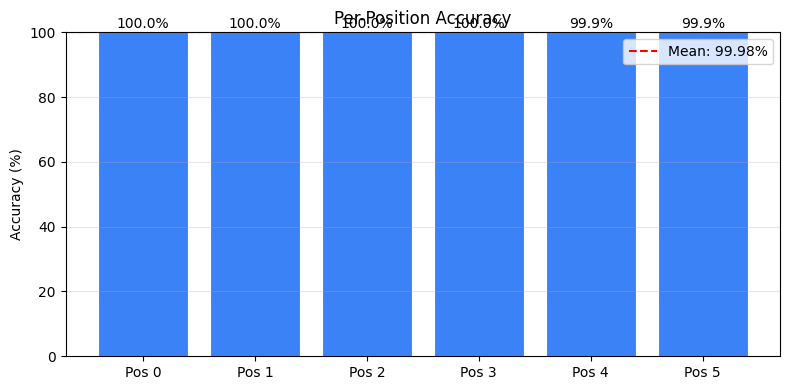

In [18]:
# ── Per-position accuracy breakdown ──────────────────────────────────────────
@torch.no_grad()
def per_position_accuracy(model, loader):
    """Returns accuracy at each of the 6 character positions."""
    model.eval()
    pos_correct = np.zeros(SEQ_LEN)
    pos_total   = np.zeros(SEQ_LEN)

    for imgs, targets in loader:
        imgs    = imgs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE)

        with autocast():
            logits = model(imgs)

        stacked = torch.stack(logits, dim=1).argmax(dim=2)  # [B, 6]
        for pos in range(SEQ_LEN):
            pos_correct[pos] += (stacked[:, pos] == targets[:, pos]).sum().item()
            pos_total[pos]   += len(targets)

    return pos_correct / pos_total


pos_acc = per_position_accuracy(model, val_loader)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f"Pos {i}" for i in range(SEQ_LEN)],
               pos_acc * 100, color="#3b82f6", edgecolor="white", linewidth=0.8)
ax.axhline(pos_acc.mean() * 100, color="red", linestyle="--",
           label=f"Mean: {pos_acc.mean():.2%}")
ax.set_ylim(0, 100); ax.set_ylabel("Accuracy (%)"); ax.set_title("Per-Position Accuracy")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, pos_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1%}", ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()


Collected 2 error examples


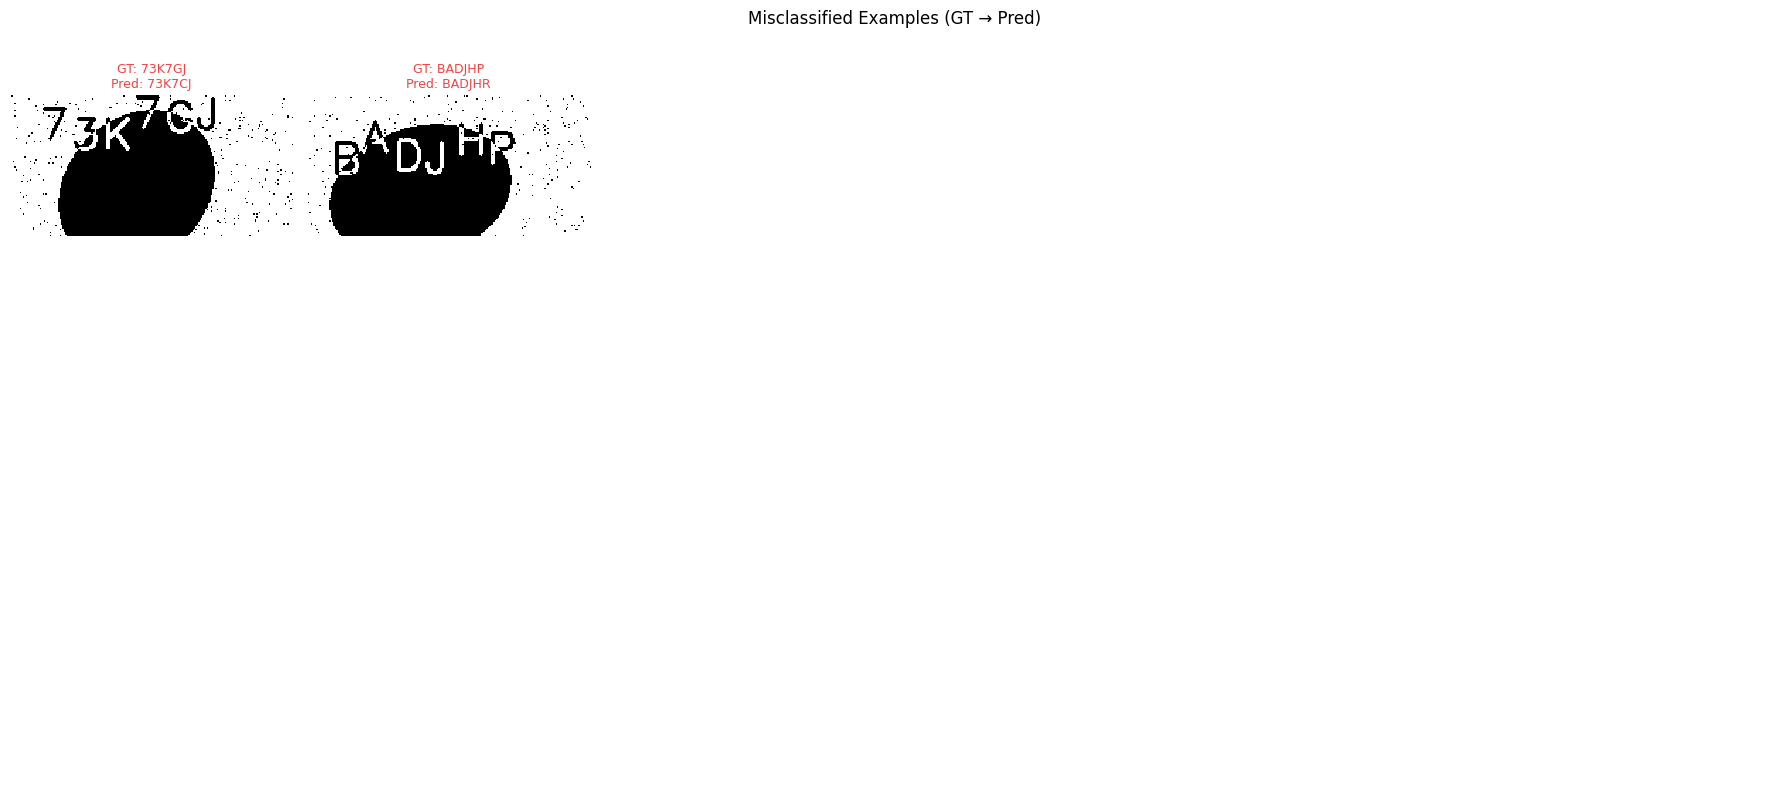

In [19]:
# ── Confusion matrix for most confusable character pairs ─────────────────────
@torch.no_grad()
def collect_errors(model, loader, n_examples=200):
    """Collect misclassified examples for qualitative inspection."""
    model.eval()
    wrong = []

    for imgs, targets in loader:
        imgs    = imgs.to(DEVICE)
        targets = targets.to(DEVICE)

        with autocast():
            logits = model(imgs)

        preds = decode_predictions(logits)
        gts   = ["".join(IDX2CHAR[i.item()] for i in t) for t in targets.cpu()]

        for img, pred, gt in zip(imgs.cpu(), preds, gts):
            if pred != gt and len(wrong) < n_examples:
                wrong.append((img, pred, gt))
        if len(wrong) >= n_examples:
            break
    return wrong


errors = collect_errors(model, val_loader)
print(f"Collected {len(errors)} error examples")

# Show a grid of errors
n_show = min(24, len(errors))
fig, axes = plt.subplots(4, 6, figsize=(18, 8))
for ax, (img, pred, gt) in zip(axes.flat, errors[:n_show]):
    arr = (img.squeeze().numpy() * 0.5 + 0.5) * 255
    ax.imshow(arr, cmap="gray", interpolation="nearest")
    color = "#ef4444"
    ax.set_title(f"GT: {gt}\nPred: {pred}", fontsize=9, color=color)
    ax.axis("off")
for ax in axes.flat[n_show:]:
    ax.axis("off")
plt.suptitle("Misclassified Examples (GT → Pred)", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 11 · Test Set Inference & Submission

In [20]:
@torch.no_grad()
def predict_test(model, loader):
    """Run inference on all test images. Returns list of (filename, prediction)."""
    model.eval()
    results = []

    for imgs, fnames in tqdm(loader, desc="Predicting"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast():
            logits = model(imgs)
        preds = decode_predictions(logits)
        results.extend(zip(fnames, preds))

    return results


test_results = predict_test(model, test_loader)
print(f"Generated {len(test_results):,} predictions")

# Preview
print("\nSample predictions:")
for fname, pred in test_results[:10]:
    print(f"  {fname:<20} →  {pred}")


Predicting:   0%|          | 0/40 [00:00<?, ?it/s]

Generated 5,000 predictions

Sample predictions:
  test-0.png           →  QVTQ8A
  test-1.png           →  7PSW9D
  test-2.png           →  WJ2WNY
  test-3.png           →  RFHJD4
  test-4.png           →  K7ZUF2
  test-5.png           →  CPMUBK
  test-6.png           →  UZDRAW
  test-7.png           →  2YDPJR
  test-8.png           →  H5SG63
  test-9.png           →  B2Z823


In [21]:
# ── Build & save submission CSV ───────────────────────────────────────────────
import re

# Sort numerically: test-0, test-1, …, test-4999
def sort_key(item):
    match = re.search(r"(\d+)", item[0])
    return int(match.group(1)) if match else 0

test_results_sorted = sorted(test_results, key=sort_key)

submission = pd.DataFrame(test_results_sorted, columns=["image", "prediction"])

# Save locally and to Drive
local_csv  = "/content/submission.csv"
drive_csv  = str(Path(CHECKPOINT_DIR) / "submission.csv")

submission.to_csv(local_csv,  index=False)
submission.to_csv(drive_csv,  index=False)

print(f"Submission saved: {local_csv}")
print(f"Submission saved: {drive_csv}")
print(f"\nShape: {submission.shape}")
print("\nFirst 10 rows:")
print(submission.head(10).to_string(index=False))
print("\nLast 5 rows:")
print(submission.tail(5).to_string(index=False))

# Sanity checks
assert len(submission) == n_test, f"Expected {n_test} rows, got {len(submission)}"
assert submission["image"].nunique() == n_test, "Duplicate image names!"
assert submission["prediction"].str.len().eq(SEQ_LEN).all(), \
    f"Not all predictions are length {SEQ_LEN}!"
valid_chars = set(VOCAB)
for pred in submission["prediction"]:
    assert all(c in valid_chars for c in pred), f"Invalid char in: {pred}"
print("\nAll sanity checks passed ✓")


Submission saved: /content/submission.csv
Submission saved: /content/checkpoints/submission.csv

Shape: (5000, 2)

First 10 rows:
     image prediction
test-0.png     QVTQ8A
test-1.png     7PSW9D
test-2.png     WJ2WNY
test-3.png     RFHJD4
test-4.png     K7ZUF2
test-5.png     CPMUBK
test-6.png     UZDRAW
test-7.png     2YDPJR
test-8.png     H5SG63
test-9.png     B2Z823

Last 5 rows:
        image prediction
test-4995.png     R5ENAF
test-4996.png     WNQH33
test-4997.png     9SYANQ
test-4998.png     9X7DDR
test-4999.png     Z2WTZ3

All sanity checks passed ✓


## 12 · Download Submission

In [22]:
from google.colab import files
files.download("/content/submission.csv")
print("Downloading submission.csv …")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13 · Visualise Test Predictions

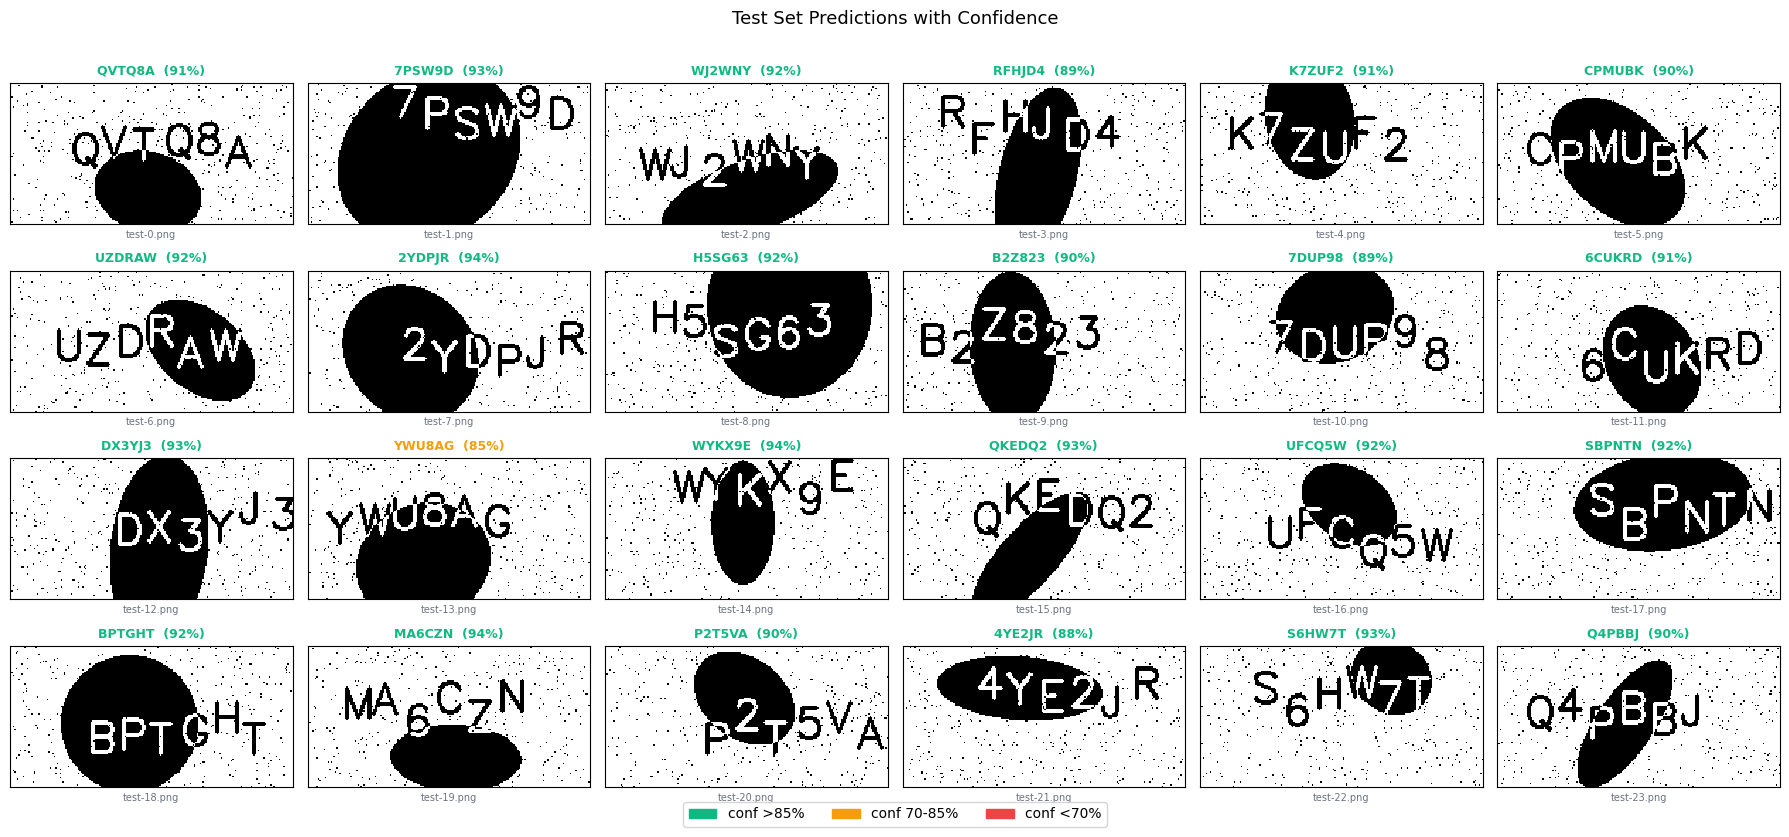

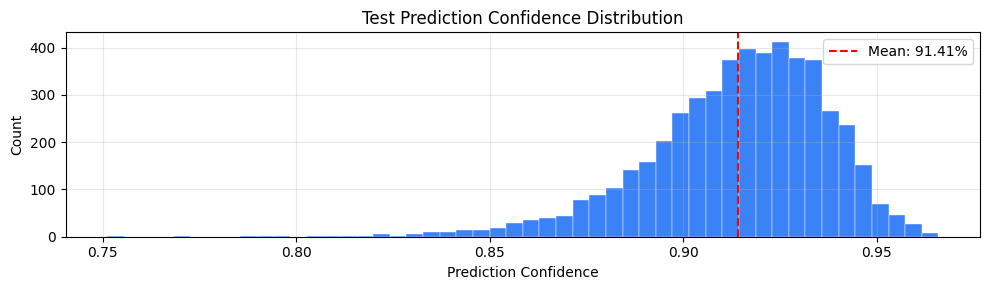

Mean confidence : 91.41%
Low-conf (<70%) : 0 images  (0.0%)


In [23]:
# Show a grid of test predictions with confidence scores
@torch.no_grad()
def predict_with_confidence(model, loader, n=24):
    """
    Returns (images, predictions, confidence) for the first n test images.
    Confidence = mean of max-softmax probability across the 6 positions.
    """
    model.eval()
    all_imgs, all_preds, all_confs, all_fnames = [], [], [], []

    for imgs, fnames in loader:
        imgs = imgs.to(DEVICE)
        with autocast():
            logits = model(imgs)

        # Confidence: mean of max softmax prob over 6 positions
        stacked   = torch.stack(logits, dim=1)          # [B,6,V]
        probs     = F.softmax(stacked.float(), dim=2)   # [B,6,V]
        max_probs = probs.max(dim=2).values             # [B,6]
        conf      = max_probs.mean(dim=1)               # [B]

        preds = decode_predictions(logits)

        all_imgs.extend(imgs.cpu())
        all_preds.extend(preds)
        all_confs.extend(conf.cpu().tolist())
        all_fnames.extend(fnames)

        if len(all_imgs) >= n:
            break

    return all_imgs[:n], all_preds[:n], all_confs[:n], all_fnames[:n]


imgs_v, preds_v, confs_v, fnames_v = predict_with_confidence(model, test_loader, n=24)

fig, axes = plt.subplots(4, 6, figsize=(18, 8))
for ax, img, pred, conf, fname in zip(axes.flat, imgs_v, preds_v, confs_v, fnames_v):
    arr = (img.squeeze().numpy() * 0.5 + 0.5) * 255
    ax.imshow(arr, cmap="gray", interpolation="nearest")
    color = "#10b981" if conf > 0.85 else "#f59e0b" if conf > 0.70 else "#ef4444"
    ax.set_title(f"{pred}  ({conf:.0%})", fontsize=9, fontweight="bold", color=color)
    ax.set_xlabel(fname, fontsize=7, color="#6b7280"); ax.set_xticks([]); ax.set_yticks([])

green_p  = mpatches.Patch(color="#10b981", label="conf >85%")
yellow_p = mpatches.Patch(color="#f59e0b", label="conf 70-85%")
red_p    = mpatches.Patch(color="#ef4444", label="conf <70%")
fig.legend(handles=[green_p, yellow_p, red_p], loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Test Set Predictions with Confidence", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# Confidence distribution
fig, ax = plt.subplots(figsize=(10, 3))
all_c, all_p, all_f = [], [], []
for imgs, fnames in test_loader:
    imgs = imgs.to(DEVICE)
    with torch.no_grad(), autocast():
        logits = model(imgs)
    stacked = torch.stack(logits, dim=1)
    probs   = F.softmax(stacked.float(), dim=2)
    conf    = probs.max(dim=2).values.mean(dim=1)
    all_c.extend(conf.cpu().tolist())

ax.hist(all_c, bins=50, color="#3b82f6", edgecolor="white", linewidth=0.3)
ax.axvline(np.mean(all_c), color="red", linestyle="--",
           label=f"Mean: {np.mean(all_c):.2%}")
ax.set_xlabel("Prediction Confidence"); ax.set_ylabel("Count")
ax.set_title("Test Prediction Confidence Distribution"); ax.legend()
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"Mean confidence : {np.mean(all_c):.2%}")
print(f"Low-conf (<70%) : {sum(c<0.7 for c in all_c)} images  ({sum(c<0.7 for c in all_c)/len(all_c):.1%})")


## 14 · Save Full Experiment Summary

In [24]:
# Save training history as JSON for later analysis
summary = {
    "vocab":             VOCAB,
    "vocab_size":        VOCAB_SIZE,
    "seq_len":           SEQ_LEN,
    "img_shape":         [IMG_H, IMG_W],
    "backbone":          BACKBONE,
    "hidden_dim":        HIDDEN_DIM,
    "dropout":           DROPOUT,
    "label_smoothing":   LABEL_SMOOTHING,
    "best_val_cer":      float(min(history["val_cer"])),
    "best_epoch":        history["val_cer"].index(min(history["val_cer"])) + 1,
    "best_val_word_acc": float(max(history["val_word_acc"])),
    "history":           {k: [float(v) for v in vals] for k, vals in history.items()},
}

summary_path = str(Path(CHECKPOINT_DIR) / "experiment_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to: {summary_path}")
print("\n" + "═"*50)
print("EXPERIMENT SUMMARY")
print("═"*50)
print(f"  Backbone       : {BACKBONE}")
print(f"  Vocab size     : {VOCAB_SIZE} chars")
print(f"  Train samples  : {len(train_loader.dataset):,}")
print(f"  Val samples    : {len(val_loader.dataset):,}")
print(f"  Best Val CER   : {summary['best_val_cer']:.4f}")
print(f"  Best Word Acc  : {summary['best_val_word_acc']:.2%}")
print(f"  Best Epoch     : {summary['best_epoch']}")
print(f"  Test samples   : {len(submission):,}")
print("═"*50)


Summary saved to: /content/checkpoints/experiment_summary.json

══════════════════════════════════════════════════
EXPERIMENT SUMMARY
══════════════════════════════════════════════════
  Backbone       : efficientnet_b0
  Vocab size     : 31 chars
  Train samples  : 17,999
  Val samples    : 1,999
  Best Val CER   : 0.0001
  Best Word Acc  : 99.95%
  Best Epoch     : 22
  Test samples   : 5,000
══════════════════════════════════════════════════
